In [ ]:
%load_ext autoreload
%autoreload 2

from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import optimize, stats
from common.utils import estimateMFPT
import warnings

warnings.filterwarnings("ignore", category=FutureWarning)

PROTEINS = ['YYAPETGTWY','YYCPETGTWY','YYDPETGQWY']
RANGES = [(4000, 4200), (3000, 3200), (3201, 3401)]
THRESHOLDS = np.round(np.arange(0.1, 0.26, 0.02), 2)

def read_colvar(path: Path) -> pd.DataFrame:
    with path.open() as f:
        for line in f:
            if line.startswith("#! FIELDS"):
                names = line.replace("#! FIELDS", "").strip().split()
                break
        else:
            raise ValueError(f"No FIELDS header in {path}")
    return pd.read_csv(path, sep=r"\s+", comment="#", names=names, engine="python")

def first_cross_times(df: pd.DataFrame, thresholds):
    rmsd = df['rmsd'].to_numpy()
    t = df['time'].to_numpy()
    acc = df['metad.acc'].to_numpy()
    out = {}
    for th in thresholds:
        idx = np.flatnonzero(rmsd > th)
        out[float(th)] = None if idx.size == 0 else float(t[idx[0]] * acc[idx[0]])
    return out

def fit_tau_and_pvalue(samples, k):
    x = np.array(sorted(samples, key=float))[:k]
    n = len(x)
    ecdf = np.arange(1, n + 1) / n
    tau = optimize.curve_fit(lambda tt, tau: 1 - np.exp(-tt / tau), x, ecdf, p0=(x.mean(),), bounds=(0, np.inf))[0][0]
    f = np.random.exponential(tau, size=1000000)
    p = stats.ks_2samp(x, f, alternative="two-sided", method="asymp")[1]
    return tau, p

def gather_samples_multi(protein: str, start: int, stop: int, thresholds):
    base = Path(f"../data/{protein}/output")
    buckets = {float(th): [] for th in thresholds}
    for i in range(start, stop):
        p = base / f"run_{i}" / f"HLDA_COLVAR_{i}"
        if not p.exists():
            print(f"Missing file: {p}")
            continue
        df = read_colvar(p)
        crosses = first_cross_times(df, thresholds)
        for th, val in crosses.items():
            if val is not None:
                buckets[th].append(val)
    rows = []
    for th, arr in buckets.items():
        if not arr:
            rows.append(dict(thresh=th, mfpt=None, k=None, pvalue=None, n=0))
            continue
        arr = np.array(arr, float)
        mfpt, k = estimateMFPT(arr, 10)
        tau, pval = fit_tau_and_pvalue(arr, k)
        rows.append(dict(thresh=th, mfpt=mfpt, k=k, pvalue=pval, n=len(arr)))
    return pd.DataFrame(rows)

all_rows = []
for protein in PROTEINS:
    for (a, b) in RANGES:
        res = gather_samples_multi(protein, a, b, THRESHOLDS)
        res['protein'] = protein
        res['start'] = a
        res['stop'] = b
        all_rows.append(res)

res = pd.concat(all_rows, ignore_index=True)
    


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


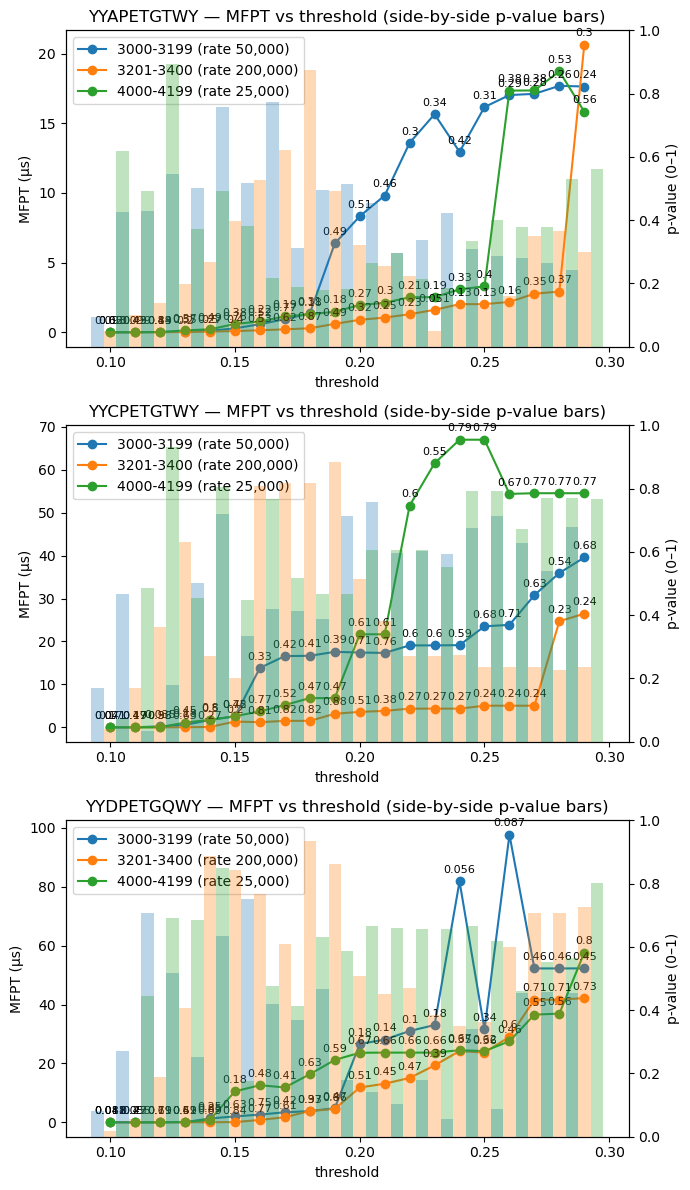

In [3]:
# RANGES = [(4000, 4201), (3000, 3201), (3201, 3401)]
rate_map = dict(zip(RANGES, ["25,000", "50,000", "200,000"]))

fig, axes = plt.subplots(len(PROTEINS), 1, figsize=(7, 4*len(PROTEINS)), squeeze=False)

bar_width = 0.005
offsets = [-bar_width, 0, bar_width]

for ax, protein in zip(axes.ravel(), PROTEINS):
    sub = res[(res.protein==protein) & res.mfpt.notna()]
    if sub.empty:
        continue

    ax2 = ax.twinx()
    ax2.set_ylim(0, 1)

    groups = list(sub.groupby(["start","stop"]))
    for j, ((a,b), g) in enumerate(groups):
        g = g.sort_values("thresh")
        y = g.mfpt.to_numpy()*1e-6

        rate = rate_map.get((int(a), int(b)), "?")
        label = f"{a}-{b-1} (rate {rate})"

        line, = ax.plot(g.thresh, y, marker="o", label=label)
        color = line.get_color()

        for x_pt, y_pt, p in zip(g.thresh, y, g.pvalue):
            ax.annotate(f"{p:.2g}", (x_pt, y_pt), xytext=(0, 6),
                        textcoords="offset points", ha="center", fontsize=8)

        ax2.bar(g.thresh + offsets[j], g.pvalue,
                width=bar_width, alpha=0.3, color=color, label=None)

    ax.set_title(f"{protein} — MFPT vs threshold (side-by-side p-value bars)")
    ax.set_xlabel("threshold")
    ax.set_ylabel("MFPT (µs)")
    ax2.set_ylabel("p-value (0–1)")
    ax.legend()

plt.tight_layout()
plt.show()
